# Airbnb - Predict

## 1 - Carga e Imports

In [1]:
# Imports
import joblib
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

In [2]:
# carga
df_rio = pd.read_csv('./processed/rio_airbnb_tratado.csv', encoding='utf-8')


In [3]:
df_rio.sample(5)

,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,neighbourhood_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,property_type_Entire rental unit,property_type_Entire serviced apartment,property_type_Other,property_type_Private room in bed and breakfast,property_type_Private room in condo,property_type_Private room in home,property_type_Private room in rental unit,property_type_Room in hotel,numero_amenities,log_price
6317,2.0,10.0,14.0,Campo Grande,-22.904700,-43.575840,2,1.0,1.0,1.0,...,False,False,False,False,False,False,True,False,5,4.007333
18677,5.0,6.0,1.0,Copacabana,-22.974020,-43.188610,2,1.0,1.0,1.0,...,True,False,False,False,False,False,False,False,37,6.368187
34104,5.0,4.0,1.0,Leme,-22.961540,-43.171000,4,1.0,1.0,2.0,...,True,False,False,False,False,False,False,False,37,7.018849
6169,4.0,4.0,1.0,Camorim,-22.985760,-43.424833,4,2.0,2.0,3.0,...,True,False,False,False,False,False,False,False,54,5.384495
32995,4.0,4.0,5.0,Leblon,-22.982257,-43.222799,3,1.0,1.0,3.0,...,True,False,False,False,False,False,False,False,13,6.347389


In [4]:
df_rio.shape

(41514, 36)

In [5]:
df_rio.isnull().sum()

hosts_time_as_user_months                          0
hosts_time_as_host_months                          0
host_listings_count                                0
neighbourhood_cleansed                             0
latitude                                           0
longitude                                          0
accommodates                                       0
bathrooms                                          0
bedrooms                                           0
beds                                               0
price                                              0
minimum_nights                                     0
maximum_nights                                     0
availability_365                                   0
number_of_reviews                                  0
estimated_occupancy_l365d                          0
review_scores_rating                               0
calculated_host_listings_count                     0
vacancia_dias                                 

### 1.1 - Criando Dicionário

In [6]:
dic_df_rio = {

    # Tempo e características do anfitrião
    "hosts_time_as_user_months": "Tempo, em meses, desde que o anfitrião entrou na plataforma como usuário.",
    
    "hosts_time_as_host_months": "Tempo, em meses, desde que o anfitrião iniciou sua atividade como anfitrião.",
    
    "host_listings_count": "Quantidade total de anúncios cadastrados pelo anfitrião.",

    "calculated_host_listings_count": "Quantidade de anúncios do anfitrião calculada a partir dos registros disponíveis no dataset.",


    # Localização
    "neighbourhood_cleansed": "Bairro ou região do imóvel após processo de padronização e limpeza dos dados.",
    
    "latitude": "Coordenada de latitude do imóvel; pode conter ajuste de privacidade e não representar a localização exata.",
    
    "longitude": "Coordenada de longitude do imóvel; pode conter ajuste de privacidade e não representar a localização exata.",


    # Características físicas e capacidade do imóvel
    "accommodates": "Número máximo de hóspedes que o imóvel pode acomodar.",
    
    "bathrooms": "Número de banheiros disponíveis no imóvel.",
    
    "bedrooms": "Número de quartos disponíveis no imóvel.",
    
    "beds": "Número de camas disponíveis no imóvel.",


    # Preço
    "price": "Preço da diária do anúncio, em Reais (R$).",
    
    "log_price": "Logaritmo natural de (price + 1), utilizado para reduzir a assimetria da distribuição da variável preço.",
    
    "faixa_preco": "Classificação categórica do anúncio em uma faixa de preço, derivada da variável price.",


    # Regras de reserva
    "minimum_nights": "Número mínimo de noites exigido para realizar uma reserva.",
    
    "maximum_nights": "Número máximo de noites permitido para uma reserva.",


    # Disponibilidade, ocupação e vacância
    "availability_365": "Quantidade de dias em que o imóvel está disponível para reserva em um período de 365 dias.",
    
    "estimated_occupancy_l365d": "Estimativa de ocupação do imóvel nos últimos 365 dias.",
    
    "vacancia_dias": "Quantidade estimada de dias em que o imóvel permaneceu vago no período analisado.",


    # Avaliações
    "number_of_reviews": "Número total de avaliações recebidas pelo anúncio.",
    
    "review_scores_rating": "Nota média geral atribuída ao imóvel pelos hóspedes.",
    
    "faixa_reviews": "Classificação categórica do anúncio em uma faixa de quantidade ou nível de avaliações.",


    # Tipo de acomodação
    "room_type_Hotel room": "Indicador binário: 1 se o tipo de acomodação for Hotel room; 0 caso contrário.",
    
    "room_type_Private room": "Indicador binário: 1 se o tipo de acomodação for Private room; 0 caso contrário.",
    
    "room_type_Shared room": "Indicador binário: 1 se o tipo de acomodação for Shared room; 0 caso contrário.",


    # Tipo de propriedade
    "property_type_Entire home": "Indicador binário: 1 se a propriedade for classificada como Entire home; 0 caso contrário.",
    
    "property_type_Entire loft": "Indicador binário: 1 se a propriedade for classificada como Entire loft; 0 caso contrário.",
    
    "property_type_Entire rental unit": "Indicador binário: 1 se a propriedade for classificada como Entire rental unit; 0 caso contrário.",
    
    "property_type_Entire serviced apartment": "Indicador binário: 1 se a propriedade for classificada como Entire serviced apartment; 0 caso contrário.",
    
    "property_type_Other": "Indicador binário: 1 se a propriedade pertencer à categoria Other; 0 caso contrário.",
    
    "property_type_Private room in bed and breakfast": "Indicador binário: 1 se a propriedade for um quarto privado em bed and breakfast; 0 caso contrário.",
    
    "property_type_Private room in condo": "Indicador binário: 1 se a propriedade for um quarto privado em condomínio; 0 caso contrário.",
    
    "property_type_Private room in home": "Indicador binário: 1 se a propriedade for um quarto privado em uma residência; 0 caso contrário.",
    
    "property_type_Private room in rental unit": "Indicador binário: 1 se a propriedade for um quarto privado em uma unidade de aluguel; 0 caso contrário.",
    
    "property_type_Room in hotel": "Indicador binário: 1 se a propriedade for classificada como um quarto em hotel; 0 caso contrário.",


    # Comodidades
    "numero_amenities": "Quantidade total de comodidades (amenities) informadas no anúncio."
}


In [7]:
# Agora é só consultar sempre que tiver dúvidas sobre cada variável
dic_df_rio['minimum_nights']

'Número mínimo de noites exigido para realizar uma reserva.'

# 2 - Eng. de Atributos

## 2.1 - Preparo e Correlação inicial

In [8]:
df_rio.head(5)

,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,neighbourhood_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,property_type_Entire rental unit,property_type_Entire serviced apartment,property_type_Other,property_type_Private room in bed and breakfast,property_type_Private room in condo,property_type_Private room in home,property_type_Private room in rental unit,property_type_Room in hotel,numero_amenities,log_price
0,5.0,0.0,1.0,Other,-22.975611,-43.284655,2,1.0,1.0,1.0,...,False,False,False,False,False,True,False,False,5,5.394127
1,4.0,5.0,27.0,Barra da Tijuca,-23.009319,-43.328026,2,1.0,1.0,2.0,...,True,False,False,False,False,False,False,False,7,6.558198
2,2.0,11.0,1.0,Copacabana,-22.963390,-43.173790,3,1.0,1.0,2.0,...,True,False,False,False,False,False,False,False,5,5.872118
3,1.0,5.0,11.0,Leme,-22.960339,-43.168939,2,1.0,1.0,1.0,...,False,False,False,False,False,True,False,False,4,5.046774
4,8.0,8.0,72.0,Ipanema,-22.984950,-43.194840,2,1.0,1.0,1.0,...,True,False,False,False,False,False,False,False,6,6.667593


In [9]:
# TRATAMENTO DE DADOS BOOLEANOS

colunas_bool = df_rio.select_dtypes(include='bool').columns

df_rio[colunas_bool] = df_rio[colunas_bool].astype(int)

In [ ]:
# VARIÁVEIS NUMÉRICAS

colunas_numericas = [
    "log_price", #ALVO
    "hosts_time_as_user_months",
    "hosts_time_as_host_months",
    "host_listings_count",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "estimated_occupancy_l365d",
    "review_scores_rating",
    "calculated_host_listings_count",
    "vacancia_dias",
    "numero_amenities",
    #dummies
    "room_type_Hotel room",
    "room_type_Private room",
    "room_type_Shared room",
    "property_type_Entire home",
    "property_type_Entire loft",
    "property_type_Entire rental unit",
    "property_type_Entire serviced apartment",
    "property_type_Other",
    "property_type_Private room in bed and breakfast",
    "property_type_Private room in condo",
    "property_type_Private room in home",
    "property_type_Private room in rental unit",
    "property_type_Room in hotel"
]


In [ ]:
# ============================
# VARIÁVEIS CATEGÓRICAS
# ============================

colunas_categoricas = [
    "neighbourhood_cleansed"
]

In [ ]:
# correlação de cada variável com o alvo (log_price), em lista ordenada

correlacao_alvo = df_rio[colunas_numericas].corr()['log_price'].drop('log_price').sort_values(ascending=False)
print(correlacao_alvo)

In [ ]:
# Ordenar pela força da relação, ignorando o sinal
correlacao_alvo_abs = correlacao_alvo.abs().sort_values(ascending=False)
print(correlacao_alvo_abs)

## 2.2 - Novos atributos

In [40]:
df_rio.sample(5)

,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,neighbourhood_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,property_type_Entire serviced apartment,property_type_Other,property_type_Private room in bed and breakfast,property_type_Private room in condo,property_type_Private room in home,property_type_Private room in rental unit,property_type_Room in hotel,log_price,faixa_amenities,score_acomodacoes
32651,6.0,10.0,4.0,Leblon,-22.981989,-43.218707,5,2.0,2.0,4.0,...,0,0,0,0,0,0,0,6.878326,"(10, 25]",13.0
39788,6.0,1.0,1.0,Other,-22.898604,-43.184464,2,1.0,1.0,1.0,...,0,1,0,0,0,0,0,5.081404,"(25, 40]",5.0
37916,8.0,6.0,4.0,Santa Teresa,-22.916815,-43.178119,2,1.0,1.0,1.0,...,1,0,0,0,0,0,0,5.771441,"(25, 40]",5.0
36468,11.0,4.0,2.0,Recreio dos Bandeirantes,-23.018630,-43.487170,4,2.0,1.0,2.0,...,0,0,0,0,0,0,0,6.244167,"(10, 25]",9.0
19291,6.0,2.0,1.0,Copacabana,-22.967748,-43.182015,2,1.0,1.0,1.0,...,0,0,0,0,0,1,0,5.686975,"(-1, 10]",5.0


In [38]:
# 1 - accommodates, bedrooms, bathrooms e beds estão todas correlacionadas entre si e com o preço

df_rio['score_acomodacoes'] = (df_rio['accommodates'] + df_rio['bathrooms'] +
                                 df_rio['bedrooms'] + df_rio['beds'])

In [42]:
# bairro score

media_por_bairro = df_rio.groupby('neighbourhood_cleansed')['log_price'].mean()
df_rio['bairro_score'] = df_rio['neighbourhood_cleansed'].map(media_por_bairro)

df_rio[['bairro_score', 'log_price']].corr()

,bairro_score,log_price
bairro_score,1.000000,0.404006
log_price,0.404006,1.000000


In [39]:
df_rio[['score_acomodacoes', 'log_price']].corr()

,score_acomodacoes,log_price
score_acomodacoes,1.000000,0.422947
log_price,0.422947,1.000000


In [44]:
# possiveis redundancias
df_rio[['host_listings_count', 'calculated_host_listings_count']].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.632631
calculated_host_listings_count,0.632631,1.000000


In [46]:
df_rio[['host_listings_count', 'calculated_host_listings_count', 'log_price']].corr()['log_price']

host_listings_count               0.015044
calculated_host_listings_count    0.062107
log_price                         1.000000
Name: log_price, dtype: float64

In [52]:
colunas_property = [c for c in df_rio.columns if c.startswith('property_type_')]

def identificar_property_type(row):
    for col in colunas_property:
        if row[col] == 1:
            return col.replace('property_type_', '')
    return 'Entire rental unit'  # categoria removida pelo drop_first (a mais frequente)

df_rio['property_type_temp'] = df_rio.apply(identificar_property_type, axis=1)

media_por_tipo = df_rio.groupby('property_type_temp')['log_price'].mean()
df_rio['property_type_score'] = df_rio['property_type_temp'].map(media_por_tipo)

df_rio[['property_type_score', 'log_price']].corr()

df_rio = df_rio.drop(columns=['property_type_temp'])  # remove a coluna auxiliar

In [53]:
df_rio[['property_type_score', 'log_price']].corr()

,property_type_score,log_price
property_type_score,1.000000,0.335278
log_price,0.335278,1.000000


O score supera qualquer dummy isolado, e ainda simplifica o dataset — 1 coluna no lugar de ~10 dummies, sem perda de informação relevante (e ainda ganha poder preditivo).

### 2.3.1 - tirar as colunas sem correlação que justifique a sua existência

In [ ]:
# código remove do dataframe todos os dummies de bairro e de tipo de imóvel

colunas_bairro = [c for c in df_rio.columns if c.startswith('neighbourhood_cleansed_')]
colunas_property = [c for c in df_rio.columns if c.startswith('property_type_') and c != 'property_type_score']

df_rio = df_rio.drop(columns=colunas_bairro + colunas_property)

In [ ]:
df_rio = df_rio.drop(columns=['host_listings_count'])

In [48]:
df_rio = df_rio.drop(columns=['faixa_amenities'])

In [50]:
df_rio = df_rio.drop(columns=['score_acomodacoes'])

In [55]:
df_rio.shape

(41514, 26)

## 3.1 - Filtrando as correlações

A correlação é uma medida da relação entre as variáveis. O coeficiente de correlação é um valor de -1 a +1, sendo:

**-1 indica alta correlação negativa.**

**+1 indica ata correlação positiva.**

**0 indica que não há correlação.**

In [61]:
# Pega todas as colunas numéricas do df_rio atual (já sem as removidas, já com as novas)
colunas_numericas_atualizada = df_rio.select_dtypes(include=[np.number]).columns.tolist()
print(colunas_numericas_atualizada)

['hosts_time_as_user_months', 'hosts_time_as_host_months', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'estimated_occupancy_l365d', 'review_scores_rating', 'calculated_host_listings_count', 'vacancia_dias', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'log_price', 'bairro_score', 'property_type_score']


In [62]:
matriz_corr = df_rio[colunas_numericas_atualizada].corr()

construir uma função para filtrar e mostrar somente o que interessa para nossa análise

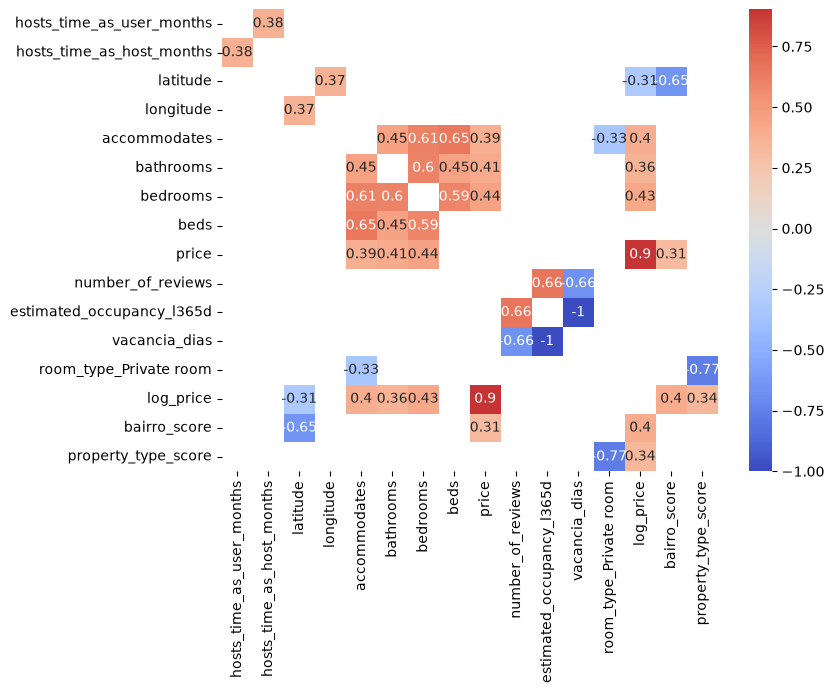

In [63]:
def filtrar_e_visualizar_correlacao(corr, threshold, drop_column=None):
    # corr já deve ser uma matriz de correlação (resultado de .corr())
    filtro = (abs(corr) >= threshold) & (corr != 1.0)
    df_filtrado = corr.where(filtro).dropna(how='all').dropna(axis=1, how='all')

    if drop_column:
        df_filtrado = df_filtrado.drop(index=drop_column, errors='ignore').drop(columns=drop_column, errors='ignore')

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_filtrado, annot=True, cmap='coolwarm', center=0)
    plt.show()

filtrar_e_visualizar_correlacao(matriz_corr, threshold=0.3)

In [ ]:
# Tirar vacancia dias
# no heatmap a correlação de -1.00 entre elas — a multicolinearidade perfeita
df_rio = df_rio.drop(columns=['vacancia_dias'])  # ou 'estimated_occupancy_l365d', escolha uma

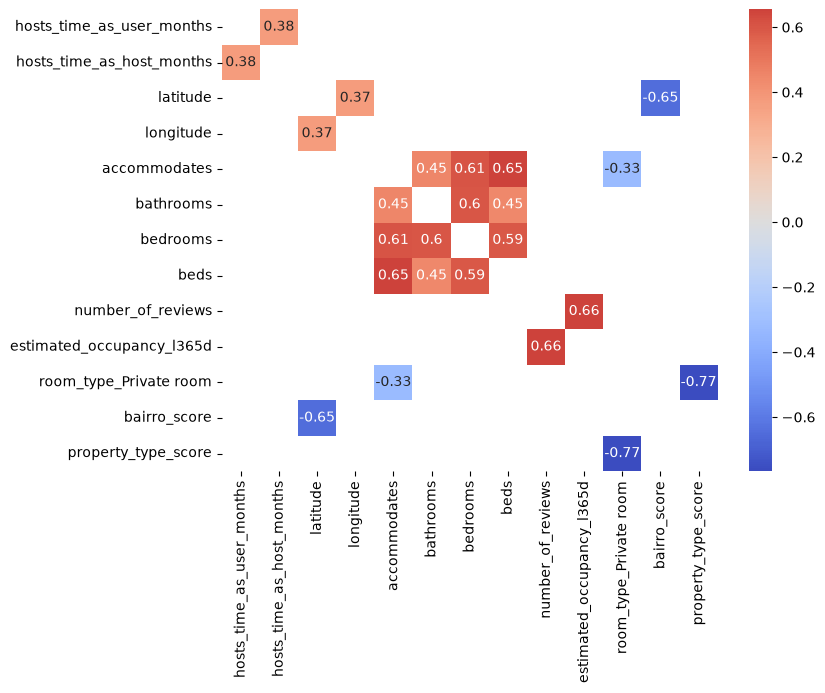

In [70]:
# Executa a função para deixar o foco só nas variáveis preditoras
filtrar_e_visualizar_correlacao(matriz_corr, threshold=0.3, drop_column=['log_price', 'price', 'vacancia_dias'])

Grupo físico (accommodates/bathrooms/bedrooms/beds) → maior risco
property_type_score vs room_type_Private room → segundo maior risco
bairro_score vs latitude → risco moderado, mas já resolvido pela superioridade preditiva do score

1. Características físicas do imóvel (grupo mais denso)
accommodates, bathrooms, bedrooms, beds — todas correlacionadas entre si (0.45 a 0.65). Isso é esperado (imóveis maiores tendem a ter mais de tudo), mas confere multicolinearidade real. Isso vai pesar na decisão do VIF: provavelmente pelo menos uma dessas 4 vai precisar ser removida ou combinada na etapa de modelagem.

2. number_of_reviews × estimated_occupancy_l365d: 0.66
Confirma o que já discutimos no EDA — reviews e ocupação se retroalimentam (mais ocupação gera mais reviews, e vice-versa). Correlação alta, mas não extrema o suficiente para ser "a mesma variável" — ainda assim, é candidata a atenção no VIF.

3. bairro_score × latitude: -0.65
Faz total sentido — as duas capturam localização. Como bairro_score teve correlação mais forte com log_price (0.404 vs -0.309 de latitude), se precisar escolher uma na modelagem, bairro_score tem vantagem.

4. property_type_score × room_type_Private room: -0.77 (a mais forte do gráfico)
Essa é a que merece mais atenção. Os dois conceitos estão logicamente entrelaçados (tipo de propriedade e tipo de cômodo andam juntos), e -0.77 já é uma correlação bem alta — no limite do que se considera preocupante para regressão linear. Vale calcular o VIF específico desse par quando chegarem na modelagem.

5. hosts_time_as_user_months × hosts_time_as_host_months: 0.38
Moderada, esperada (quem é host há mais tempo geralmente também é usuário da plataforma há mais tempo), não é motivo de alarme imediato.

## 3.2 - VIF (variance_inflation_factor)

In [72]:
df_rio.columns

Index(['hosts_time_as_user_months', 'hosts_time_as_host_months',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'estimated_occupancy_l365d', 'review_scores_rating',
       'calculated_host_listings_count', 'faixa_preco', 'faixa_reviews',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'log_price', 'bairro_score',
       'property_type_score'],
      dtype='str')

In [73]:
# Lista de VIF

colunas_vif = [
    'hosts_time_as_user_months',
    'hosts_time_as_host_months',
    'latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'availability_365',
    'number_of_reviews',
    'estimated_occupancy_l365d',
    'review_scores_rating',
    'calculated_host_listings_count',
    'room_type_Hotel room',
    'room_type_Private room',
    'room_type_Shared room',
    'bairro_score',
    'property_type_score'
]

X = df_rio[colunas_vif].assign(const=1)

vif_dados = pd.DataFrame()
vif_dados['variavel'] = X.columns
vif_dados['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_dados.sort_values('VIF', ascending=False)

,variavel,VIF
19,property_type_score,3.334381
16,room_type_Private room,3.165161
2,latitude,2.322975
6,bedrooms,2.225705
4,accommodates,2.212804
18,bairro_score,2.029668
7,beds,2.016677
12,estimated_occupancy_l365d,1.899362
11,number_of_reviews,1.819863
5,bathrooms,1.647755


*"Minhas variáveis preditoras (X) são redundantes entre si?"*

Interpretando os números

A regra prática mais usada para VIF é:

- VIF < 5: sem problema relevante de multicolinearidade
- VIF entre 5 e 10: atenção, pode ser problemático dependendo do contexto
- VIF > 10: multicolinearidade severa, quase sempre exige ação

Olhando a tabela, o maior valor é 3.33 (property_type_score) — bem abaixo até do limiar mais rigoroso de 5. Isso significa que, apesar das correlações "visualmente fortes" que vimos no heatmap (como -0.77 entre property_type_score e room_type_Private room), elas não chegam a comprometer a estabilidade dos coeficientes da regressão quando avaliadas em conjunto com todas as outras variáveis.

Por que isso é diferente do que o heatmap sugeria

Correlação simples (par a par) e VIF medem coisas relacionadas, mas não idênticas: o heatmap mostra a relação entre duas variáveis isoladamente, enquanto o VIF mede o quanto uma variável pode ser "prevista" por todas as outras combinadas. Uma correlação de -0.77 entre duas variáveis específicas pode não virar um VIF alto se o restante do conjunto de variáveis "dilui" essa redundância.

O que isso significa na prática

Você não precisa remover nenhuma variável por motivo de multicolinearidade — o conjunto atual está estatisticamente saudável para regressão linear. Isso é um bom sinal de que o trabalho de engenharia de atributos (os scores substituindo os dummies excessivos) ajudou a manter o dataset enxuto sem introduzir redundância problemática.

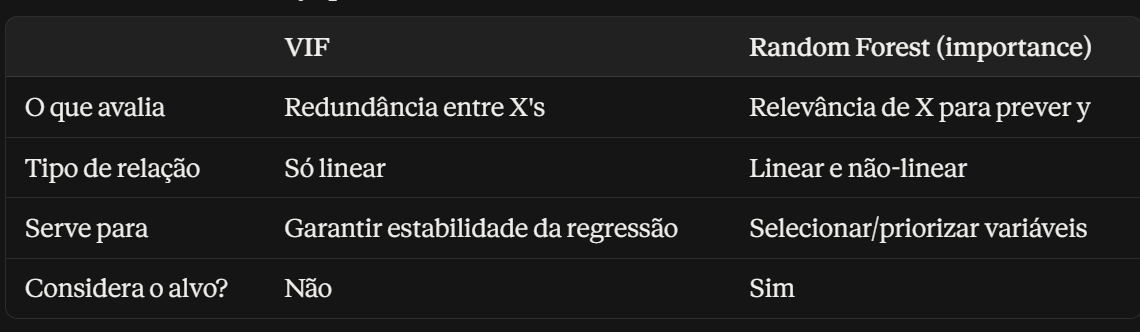

## 3.3 - Usando ML Para Encontrar as Variáveis Mais Relevantes

*Quais variáveis realmente importam para prever o alvo?*

algoritmo RandomForest, que é um tipo de algoritmo de aprendizado de máquina baseado em árvores de decisão, é considerado uma boa opção para encontrar as variáveis mais relevantes (ou "importantes") em um dataset por várias razões:

Redução de variância: O RandomForest combina várias árvores de decisão, cada uma construída com uma amostra aleatória do dataset. Isso ajuda a reduzir a variância e a evitar o overfitting, o que significa que o modelo pode generalizar melhor para novos dados.

Importância de variáveis: Durante a construção das árvores, o RandomForest avalia a importância de cada variável com base em quanto ela contribui para a melhoria da pureza dos nós (por exemplo, usando o ganho de informação ou a redução da impureza de Gini). Essa avaliação é agregada em todas as árvores para fornecer uma medida de importância para cada variável.

Robustez a ruídos e outliers: Como o RandomForest é baseado em árvores de decisão, ele é naturalmente robusto a ruídos e outliers nos dados. Isso o torna uma opção confiável para identificar variáveis importantes, mesmo em datasets com essas características.

Facilidade de interpretação: As medidas de importância de variáveis geradas pelo RandomForest são fáceis de interpretar, o que facilita a compreensão de quais variáveis são mais relevantes para a tarefa em questão.

Flexibilidade: O RandomForest pode lidar com diferentes tipos de dados (numéricos, categóricos) e é adequado para uma variedade de tarefas de aprendizado de máquina, como classificação e regressão.

Por essas razões, o RandomForest é frequentemente utilizado para selecionar as variáveis mais relevantes em um dataset, o que pode ajudar a simplificar o modelo e melhorar seu desempenho em tarefas de predição.

In [ ]:
df_rio.columns


Index(['hosts_time_as_user_months', 'hosts_time_as_host_months',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'estimated_occupancy_l365d', 'review_scores_rating',
       'calculated_host_listings_count', 'faixa_preco', 'faixa_reviews',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'log_price', 'bairro_score',
       'property_type_score'],
      dtype='str')

In [77]:
X = df_rio[colunas_vif].drop(columns=['const'], errors='ignore')  # remove a constante do VIF
y = df_rio["log_price"]


In [78]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [79]:
# Inicializando e treinando o RandomForestRegressor
modelo = RandomForestRegressor(n_estimators = 100, random_state = 42)
modelo.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [80]:
# Fazendo previsões com o conjunto de teste
y_pred = modelo.predict(X_test)

In [81]:
# Avaliando o modelo
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse}")

RMSE: 0.42565760973338745


In [82]:
print('R2 Score:', metrics.r2_score(y_test, y_pred))

R2 Score: 0.6112209559863878


In [83]:
# Identificando a importância das variáveis .feature_importances_
importancias = modelo.feature_importances_
variaveis = X.columns

In [84]:
# Dataframe das variáveis mais relevantes
importancias_df = pd.DataFrame({'Variável': variaveis, 
                                'Importância': importancias}).sort_values(by = 'Importância', 
                                                                          ascending = False)

In [85]:
print(importancias_df)

                          Variável  Importância
6                         bedrooms     0.221716
18                    bairro_score     0.105868
2                         latitude     0.085294
3                        longitude     0.082696
12       estimated_occupancy_l365d     0.068809
10                availability_365     0.059558
5                        bathrooms     0.051883
4                     accommodates     0.039888
19             property_type_score     0.037836
14  calculated_host_listings_count     0.031613
1        hosts_time_as_host_months     0.029963
0        hosts_time_as_user_months     0.029669
13            review_scores_rating     0.027753
11               number_of_reviews     0.027319
9                   maximum_nights     0.027073
8                   minimum_nights     0.020772
17           room_type_Shared room     0.020680
7                             beds     0.016245
16          room_type_Private room     0.015211
15            room_type_Hotel room     0


#### 3.3.1 RESUMO — Seleção de Variáveis Preditoras (VIF + Random Forest)

MULTICOLINEARIDADE (VIF):
- Todas as variáveis apresentaram VIF < 5 (máximo: 3.33, property_type_score).
- Conclusão: não há problema relevante de multicolinearidade no conjunto atual.
  Os coeficientes de uma regressão linear com essas variáveis tendem a ser
  estáveis e interpretáveis.

IMPORTÂNCIA DE VARIÁVEIS (Random Forest):
- Performance do modelo: R² = 0.61 | RMSE = 0.43 (em escala log_price)
- Top variáveis por importância: bedrooms, bairro_score, latitude, longitude,
  estimated_occupancy_l365d, availability_365, bathrooms

PRINCIPAIS ACHADOS:
1. Convergência entre métodos: bedrooms, bairro_score e bathrooms aparecem
   como relevantes tanto na correlação linear (EDA) quanto no Random Forest
   — reforça confiança nesses achados.

2. Divergência importante — geografia: latitude e longitude tiveram baixa
   correlação linear individual, mas alta importância no Random Forest.
   Isso sugere uma relação NÃO-LINEAR com o preço (provavelmente a posição
   geográfica combinada, não cada eixo isoladamente, é o que importa).
   Juntas, lat+long superam bairro_score em importância combinada.

3. Divergência — ocupação/disponibilidade: estimated_occupancy_l365d e
   availability_365 tiveram maior importância no RF do que a correlação
   linear sugeria. ATENÇÃO: estimated_occupancy_l365d tem relação de
   causalidade ambígua com preço (pode ser efeito, não causa) — usar
   com cautela na interpretação do modelo final.

4. Redundância detectada: property_type_score teve correlação linear forte
   isoladamente (0.335), mas baixa importância no RF (0.038) — indica que
   sua informação já é capturada por bedrooms/bathrooms/accommodates
   quando todas as variáveis são consideradas juntas.

5. Candidatas a remoção (importância ~0): room_type_Hotel room (0.0002).

PRÓXIMOS PASSOS:
- Validar via statsmodels OLS (coeficientes, p-values, R² ajustado)
- Testar modelo enxuto (sem property_type_score / room_type_Hotel room)
  vs. modelo completo
- Ao montar o modelo final: recalcular bairro_score e property_type_score
  usando SOMENTE dados de treino (evitar vazamento de dados)


### 3.4 - Coeficientes - StatsModels OLS 

- Qual o efeito exato (coeficiente) de cada variável, ele é estatisticamente significativo, e o modelo linear é adequado? 

Essa análise é essencial para a "significância estatística" de cada variável

In [86]:
import statsmodels.api as sm

# usar o mesmo X_train/y_train do Random Forest, sem a coluna 'const' manual
# (sm.add_constant já adiciona o intercepto automaticamente)

X_train_sm = sm.add_constant(X_train)
modelo_ols = sm.OLS(y_train, X_train_sm.astype(float))
resultado_ols = modelo_ols.fit()

print(resultado_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     1509.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:20:05   Log-Likelihood:                -23873.
No. Observations:               33211   AIC:                         4.779e+04
Df Residuals:                   33190   BIC:                         4.797e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

O alerta: [2] The condition number is large, 5.08e+05. This might indicate that there 
    are strong multicollinearity or other numerical problems.

Isso parece contradizer o VIF (que deu tudo abaixo de 3.5), mas na verdade não é bem uma contradição — é uma limitação diferente.

Quando variáveis têm escalas tão diferentes (maximum_nights varia em centenas/milhares; latitude varia só entre -23 e -22; accommodates entre 1 e 16), isso infla o condition number mesmo sem multicolinearidade real entre elas — é mais um problema numérico de escala do que de redundância de informação.

A correção mais comum: padronizar as variáveis:

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_train_sm = sm.add_constant(X_train_scaled)
modelo_ols = sm.OLS(y_train, X_train_sm.astype(float))
resultado_ols = modelo_ols.fit()
print(resultado_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     1509.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:22:17   Log-Likelihood:                -23873.
No. Observations:               33211   AIC:                         4.779e+04
Df Residuals:                   33190   BIC:                         4.797e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### 3.4.1 - RESULTADOS — Regressão Linear (OLS, variáveis padronizadas)

R² = 0.476 (vs. 0.61 do Random Forest — sinal de relação não-linear residual)
Condition Number: 4.37 (multicolinearidade resolvida após padronização)

Variáveis SEM significância estatística (candidatas a remoção):
- hosts_time_as_user_months (p=0.857)
- number_of_reviews (p=0.588)
- room_type_Hotel room (p=0.207, amostra pequena: 23 imóveis)

Maiores efeitos (coeficientes padronizados):
1. bairro_score (+0.183) — localização é o efeito individual mais forte
2. estimated_occupancy_l365d (-0.150) — mais ocupação, menor preço
   (cautela: causalidade ambígua)
3. room_type_Shared room (-0.122) — quartos compartilhados, mais baratos
4. bedrooms (+0.125), accommodates (+0.120) — atributos físicos fortes
5. beds (-0.027) — negativo mesmo controlando accommodates/bedrooms,
   sugere formato "compartilhado/econômico"

Diagnóstico de resíduos:
- Não-normalidade detectada (Jarque-Bera, Omnibus significativos)
- Sem autocorrelação (Durbin-Watson ≈ 2.0)

### 3.5 - Modelo enxuto

Removendo as 3 variáveis sem significância estatística:

In [88]:
# Removendo variáveis não significativas
colunas_remover = ['hosts_time_as_user_months', 'number_of_reviews', 'room_type_Hotel room']

X_train_enxuto = X_train_scaled.drop(columns=colunas_remover)

X_train_sm_enxuto = sm.add_constant(X_train_enxuto)
modelo_ols_enxuto = sm.OLS(y_train, X_train_sm_enxuto.astype(float))
resultado_ols_enxuto = modelo_ols_enxuto.fit()

print(resultado_ols_enxuto.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     1775.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:28:36   Log-Likelihood:                -23874.
No. Observations:               33211   AIC:                         4.778e+04
Df Residuals:                   33193   BIC:                         4.794e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### 3.5.1 - MODELO FINAL (OLS enxuto, 17 variáveis)

Removidas por falta de significância estatística: 
hosts_time_as_user_months, number_of_reviews, room_type_Hotel room

Resultado da simplificação:
- R² / R² Adj.: 0.476 (idêntico ao modelo completo — sem perda)
- AIC/BIC: levemente melhores (4.778e+04 / 4.794e+04)
- Todas as 17 variáveis restantes são estatisticamente significativas (p<0.05)
- Condition Number: 4.36 (sem problema de multicolinearidade)

Conclusão: modelo mais parcimonioso, sem perda de poder explicativo.

In [89]:
colunas_remover_fracas = ['hosts_time_as_host_months', 'maximum_nights', 'calculated_host_listings_count']

X_train_super_enxuto = X_train_enxuto.drop(columns=colunas_remover_fracas)
X_train_sm_super = sm.add_constant(X_train_super_enxuto)
resultado_super_enxuto = sm.OLS(y_train, X_train_sm_super.astype(float)).fit()

print(resultado_super_enxuto.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     2152.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:34:51   Log-Likelihood:                -23886.
No. Observations:               33211   AIC:                         4.780e+04
Df Residuals:                   33196   BIC:                         4.793e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

##### TESTE DE PARCIMÔNIA: modelo enxuto (17 vars) vs. super enxuto (14 vars)

Removidas adicionalmente: hosts_time_as_host_months, maximum_nights,
                            calculated_host_listings_count

Resultado: AIC piorou levemente (4.778e+04 → 4.780e+04), BIC melhorou
levemente (4.794e+04 → 4.793e+04) — critérios divergentes, indicando
zona de indiferença estatística.

DECISÃO: manter o modelo de 17 variáveis (melhor resultado sem trade-off
em nenhum critério na rodada anterior). As variáveis de efeito pequeno
(minimum_nights, calculated_host_listings_count, hosts_time_as_host_months)
permanecem no modelo por significância estatística válida, mas são
interpretadas como de baixo impacto prático na análise final.


### Diagnóstico visual

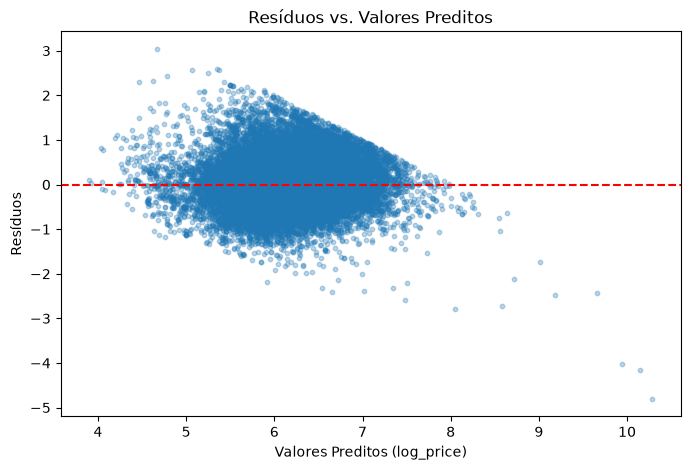

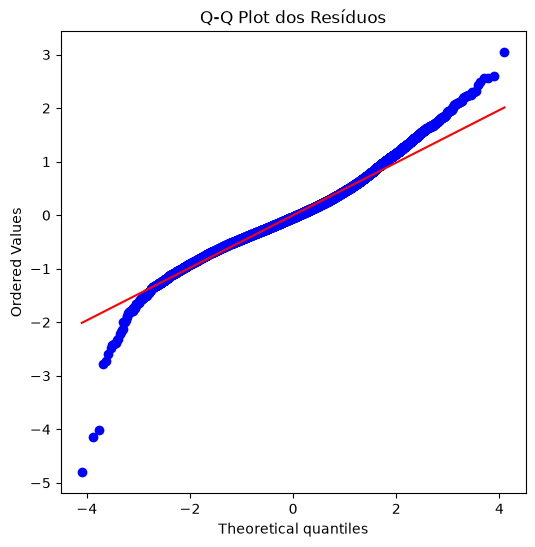

In [90]:
import matplotlib.pyplot as plt
import scipy.stats as stats

residuos = resultado_ols.resid
preditos = resultado_ols.fittedvalues

# 1. Resíduos vs. valores preditos (checa heterocedasticidade)
plt.figure(figsize=(8, 5))
plt.scatter(preditos, residuos, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Preditos (log_price)')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Preditos')
plt.show()

# 2. Q-Q plot (checa normalidade)
plt.figure(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Q-Q Plot dos Resíduos')
plt.show()

### 4 - Correção no dataset

Aparentemente, há valores de outliers que estão atrapalhando os cálculos. 

Será necessário investigar um pouco mais

In [91]:
# recalcula só os erros-padrão/p-values de forma mais confiável diante da heterocedasticidade
resultado_robusto = modelo_ols_enxuto.fit(cov_type='HC3')
print(resultado_robusto.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     1488.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:40:33   Log-Likelihood:                -23874.
No. Observations:               33211   AIC:                         4.778e+04
Df Residuals:                   33193   BIC:                         4.794e+04
Df Model:                          17                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [92]:
df_rio.loc[X_train.index[residuos < -3]][['price', 'log_price', 'bairro_score', 'accommodates', 'bedrooms']]

,price,log_price,bairro_score,accommodates,bedrooms
29515,375.5,5.930918,6.242550,16,11.0
36926,239.0,5.480639,5.849062,16,24.0
40478,400.0,5.993961,5.849062,6,26.0


imóveis com 26 quartos e 6 acomodantes, ou 24 quartos e 16 acomodantes — isso não parece um apartamento residencial comum. Parece muito mais um hostel, pousada ou prédio inteiro cadastrado como um único anúncio (26 quartos para acomodar só 6 pessoas não faz sentido físico para uma unidade residencial única)

In [93]:
# Verificar imóveis com relação atípica entre quartos e capacidade
suspeitos = df_rio[df_rio['bedrooms'] > df_rio['accommodates']]
print(f"Total de casos suspeitos: {len(suspeitos)}")
print(suspeitos[['price', 'bedrooms', 'accommodates', 'bathrooms']].describe())

Total de casos suspeitos: 137
             price    bedrooms  accommodates   bathrooms
count   137.000000  137.000000    137.000000  137.000000
mean    521.163212    5.094891      2.080292    2.288321
std     537.446689    5.184654      2.268902    2.246503
min      47.470000    2.000000      1.000000    1.000000
25%     172.000000    3.000000      1.000000    1.000000
50%     320.000000    3.000000      2.000000    2.000000
75%     639.060000    4.000000      2.000000    3.000000
max    2309.740000   27.000000     16.000000   16.000000


In [94]:
df_rio['diferenca_quartos_acomodantes'] = df_rio['bedrooms'] - df_rio['accommodates']
df_rio['diferenca_quartos_acomodantes'].describe()

# Ver quantos têm uma diferença muito grande (ex: mais de 5 quartos "a mais")
casos_extremos = df_rio[df_rio['diferenca_quartos_acomodantes'] > 5]
print(f"Casos extremos: {len(casos_extremos)}")
print(casos_extremos[['price', 'bedrooms', 'accommodates']].sort_values('bedrooms', ascending=False))

Casos extremos: 20
         price  bedrooms  accommodates
7225   2055.00      27.0            16
7250    114.12      27.0            16
40478   400.00      26.0             6
5574   1382.89      25.0             2
5584   1448.00      25.0             1
36926   239.00      24.0            16
41068   217.00      17.0             6
5526    196.33      13.0             2
5539    930.89      13.0             2
3294    811.00      12.0             2
38339  2283.00      11.0             2
21782  2309.74      11.0             3
36993  2283.00      11.0             2
3315    286.00      10.0             2
3321    297.00      10.0             2
6259    234.00      10.0             2
40726   152.00      10.0             1
40617   400.00      10.0             4
40727   169.00      10.0             1
37351   456.67       7.0             1


In [95]:
df_rio = df_rio[df_rio['diferenca_quartos_acomodantes'] <= 5]
df_rio = df_rio.drop(columns=['diferenca_quartos_acomodantes'])  # remove a coluna auxiliar
print(df_rio.shape)

(41494, 25)


### 5 - Re-treinando o modelo após ajustes

In [96]:
X = df_rio[colunas_vif]  # sem 'const', que era só para o VIF
y = df_rio['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# usando a lista de 17 variáveis (já sem as 3 não significativas)
X_train_enxuto = X_train_scaled.drop(columns=['hosts_time_as_user_months', 'number_of_reviews', 'room_type_Hotel room'])

X_train_sm_enxuto = sm.add_constant(X_train_enxuto)
resultado_novo = sm.OLS(y_train, X_train_sm_enxuto.astype(float)).fit(cov_type='HC3')

print(resultado_novo.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     1500.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:47:18   Log-Likelihood:                -23609.
No. Observations:               33195   AIC:                         4.725e+04
Df Residuals:                   33177   BIC:                         4.741e+04
Df Model:                          17                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### REFINAMENTO: remoção de 20 imóveis com relação bedrooms/accommodates implausível (ex: 27 quartos para 16 pessoas)

Resultado: R² Adj. 0.476 → 0.479 | AIC 4.778e+04 → 4.725e+04 (melhora
significativa) | Kurtosis 4.844 → 4.638 (resíduos mais próximos do normal)

Achado: coeficiente de 'bedrooms' ficou mais estável (erro-padrão reduzido,
z-score de 9.1 para 20.7) — confirma que os outliers extremos distorciam
especificamente essa variável.

Conclusão: a limpeza adicional, mesmo pequena (20 linhas, 0.06% do 
dataset), teve impacto desproporcional e positivo na qualidade do ajuste.

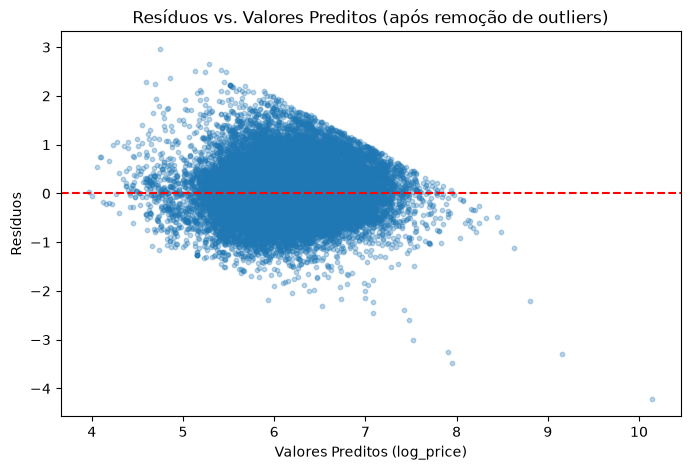

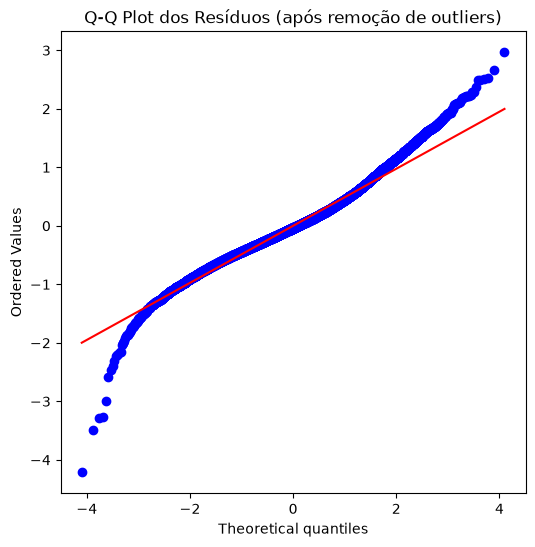

In [97]:
import matplotlib.pyplot as plt
import scipy.stats as stats

residuos = resultado_novo.resid
preditos = resultado_novo.fittedvalues

# 1. Resíduos vs. valores preditos (checa heterocedasticidade)
plt.figure(figsize=(8, 5))
plt.scatter(preditos, residuos, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Preditos (log_price)')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Preditos (após remoção de outliers)')
plt.show()

# 2. Q-Q plot (checa normalidade)
plt.figure(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Q-Q Plot dos Resíduos (após remoção de outliers)')
plt.show()

#### DIAGNÓSTICO FINAL DE RESÍDUOS (pós-remoção de 20 outliers)

- Heterocedasticidade: reduzida, mas não eliminada. Padrão de cunha
  persiste (resíduos mais negativos em preços preditos altos).
- Normalidade: leve melhora nas caudas, mas desvio da normal
  permanece nos extremos.
- Mitigação aplicada: uso de erros-padrão robustos (HC3), que
  tornam p-values e IC confiáveis mesmo com heterocedasticidade
  residual.
- Conclusão: o modelo linear captura bem a tendência central
  (R² Adj. = 0.479), mas tem limitações estruturais em extremos
  de preço — coerente com a diferença de performance observada
  frente ao Random Forest (R² = 0.61), que capta relações
  não-lineares que o OLS não alcança.

## 6 - Modelagem Preditiva

### 6.1 - Modelo Padrão Benchmark

In [99]:
# Base: df_rio já limpo (41.494 linhas, sem os 20 outliers de bedrooms/accommodates)
colunas_finais = [
    'hosts_time_as_host_months', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d', 'review_scores_rating',
    'calculated_host_listings_count', 'room_type_Private room',
    'room_type_Shared room', 'bairro_score', 'property_type_score'
]

# Separar as variávis
X = df_rio[colunas_finais]
y = df_rio['log_price']


In [100]:
# Split — use random_state=42 para bater com o que já foi feito no statsmodels
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [102]:
# Scaler — fit SOMENTE com treino
scaler = StandardScaler()
scaler.fit(X_treino)

X_treino_scaled = scaler.transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

In [103]:
# Modelo
modelo_dsa_v1 = LinearRegression()
modelo_dsa_v1.fit(X_treino_scaled, y_treino)

print("Coeficientes:\n", modelo_dsa_v1.coef_)

Coeficientes:
 [ 0.00655476 -0.07632141  0.09352155  0.10670009  0.08117539  0.15436186
 -0.03735829  0.0185553  -0.00554787  0.03619051 -0.15174864  0.05274198
  0.01083761 -0.06399799 -0.11341031  0.18032386  0.07005129]


In [104]:

comparacao = pd.DataFrame({
    'variavel': X.columns,
    'coef_sklearn': modelo_dsa_v1.coef_
})
print(comparacao)

                          variavel  coef_sklearn
0        hosts_time_as_host_months      0.006555
1                         latitude     -0.076321
2                        longitude      0.093522
3                     accommodates      0.106700
4                        bathrooms      0.081175
5                         bedrooms      0.154362
6                             beds     -0.037358
7                   minimum_nights      0.018555
8                   maximum_nights     -0.005548
9                 availability_365      0.036191
10       estimated_occupancy_l365d     -0.151749
11            review_scores_rating      0.052742
12  calculated_host_listings_count      0.010838
13          room_type_Private room     -0.063998
14           room_type_Shared room     -0.113410
15                    bairro_score      0.180324
16             property_type_score      0.070051


In [105]:
# Previsões com dados de treino
y_pred_treino_v1 = modelo_dsa_v1.predict(X_treino_scaled)

In [106]:
# Print das métricas em treino
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v1))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v1))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v1)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v1))

Mean Absolute Error: 0.37284555561078836
Mean Squared Error: 0.24282319871678754
Root Mean Squared Error: 0.49277093939962363
R2 Score: 0.47921412677218755


In [107]:
# Convertendo previsões de volta para a escala de preço real
y_pred_treino_real = np.expm1(y_pred_treino_v1)
y_treino_real = np.expm1(y_treino)

mae_real = metrics.mean_absolute_error(y_treino_real, y_pred_treino_real)
print(f"Erro médio absoluto em R$: {mae_real:.2f}")

Erro médio absoluto em R$: 220.40


In [108]:
y_pred_teste_v1 = modelo_dsa_v1.predict(X_teste_scaled)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste_v1))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste_v1))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v1)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste_v1))

Mean Absolute Error: 0.37792548398053777
Mean Squared Error: 0.247881989476429
Root Mean Squared Error: 0.4978774844039736
R2 Score: 0.4862051884438565


In [109]:
# Função para criar gráfico de dispersão
def dsa_cria_scatter(x, y, title, xlabel, ylabel):
    
    # Figura e subplots
    fig, ax = plt.subplots(figsize = (10, 6))
    
    # Scatter
    ax.scatter(x, y, color = "blue", alpha = 0.3)

    # Labels
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return

In [110]:
# Criando o dataframe de previsões
df_previsoes = pd.DataFrame({
    'Valor_Real': y_teste,
    'Valor_Previsto': y_pred_teste_v1
})

df_previsoes.head()

,Valor_Real,Valor_Previsto
37223,5.370638,5.416756
32404,6.281014,7.027380
25729,7.499977,6.794432
20948,5.771441,6.402806
14365,7.596593,6.672486


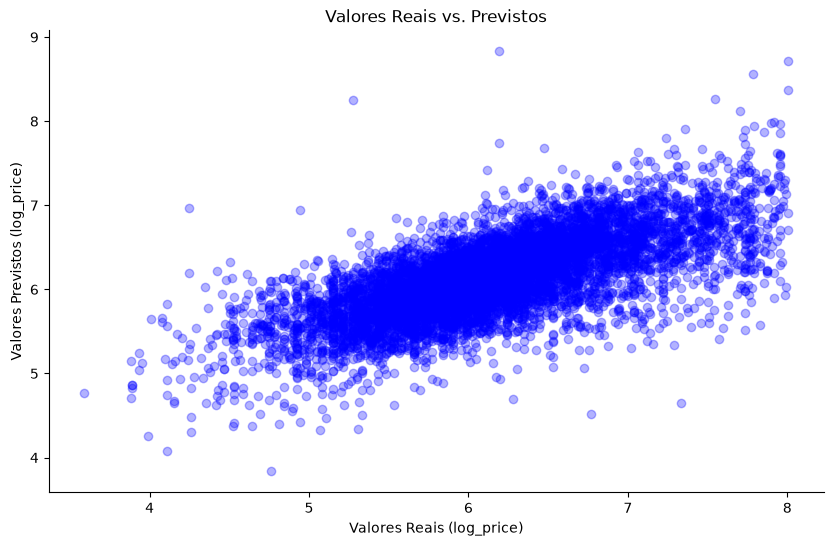

In [112]:
dsa_cria_scatter(df_previsoes.Valor_Real, df_previsoes.Valor_Previsto, 
                  'Valores Reais vs. Previstos', 'Valores Reais (log_price)', 'Valores Previstos (log_price)')

adicionar a linha de referência (y = x)

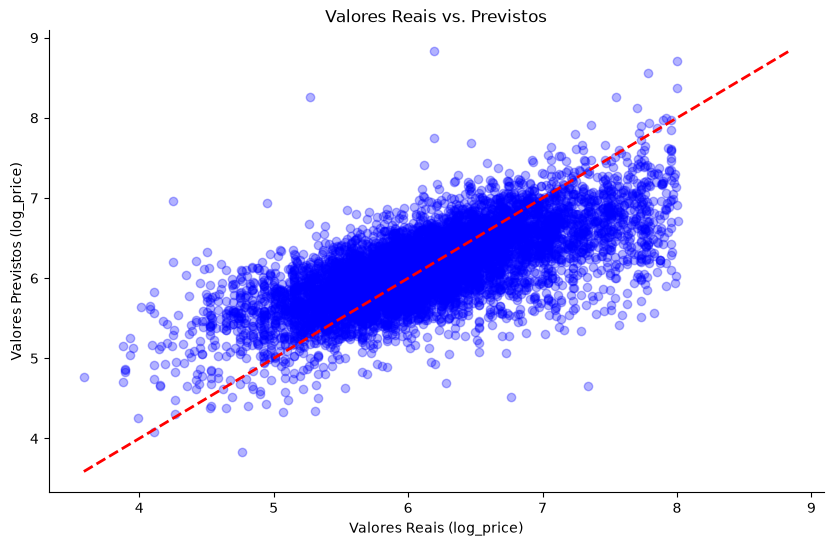

In [113]:
def dsa_cria_scatter(x, y, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(x, y, color="blue", alpha=0.3)
    
    # Linha de referência (previsão perfeita)
    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return

dsa_cria_scatter(df_previsoes.Valor_Real, df_previsoes.Valor_Previsto,
                  'Valores Reais vs. Previstos', 'Valores Reais (log_price)', 'Valores Previstos (log_price)')

### 6.2 - Regressão Lasso (Regularização L1)

In [114]:
# O alpha controla a força da regularização
modelo_v2 = Lasso(alpha = 1.0)  # alpha por experimenação - pode tentar outros valores.

In [115]:
# Treina o modelo
modelo_v2.fit(X_treino_scaled, y_treino)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [116]:
# Previsões com dados de treino
y_pred_treino_v2 = modelo_v2.predict(X_treino_scaled)

In [117]:
# Print das métricas em treino
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v2))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v2))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v2)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v2))

Mean Absolute Error: 0.5373292914238886
Mean Squared Error: 0.4662630290099421
Root Mean Squared Error: 0.6828345546396595
R2 Score: 0.0


O R² = 0.0 é um sinal claro do que aconteceu: o alpha = 1.0 foi regularização forte demais, e o Lasso "zerou" todos (ou quase todos) os coeficientes

In [118]:
print(modelo_v2.coef_)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


correção, com o LassoCV, que encontra o alpha ideal automaticamente:

In [119]:
from sklearn.linear_model import LassoCV

modelo_v2 = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, random_state=42)
modelo_v2.fit(X_treino_scaled, y_treino)

print(f"Melhor alpha encontrado: {modelo_v2.alpha_}")
print(f"Coeficientes: {modelo_v2.coef_}")

y_pred_treino_v2 = modelo_v2.predict(X_treino_scaled)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v2))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v2))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v2)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v2))

Melhor alpha encontrado: 0.0001
Coeficientes: [ 0.00644099 -0.07613447  0.09330483  0.10649814  0.0810949   0.15428064
 -0.03703507  0.01851174 -0.00547325  0.03605475 -0.15163973  0.05262254
  0.01074508 -0.06385655 -0.11330999  0.18035621  0.07013245]
Mean Absolute Error: 0.3728435341343752
Mean Squared Error: 0.2428233887947935
Root Mean Squared Error: 0.492771132266079
R2 Score: 0.479213719109572


rodar a mesma verificação em teste (para o Lasso)

In [ ]:
# verificação em teste
y_pred_teste_v2 = modelo_v2.predict(X_teste_scaled)

print('R2 Score (teste):', metrics.r2_score(y_teste, y_pred_teste_v2))

R2 Score (teste): 0.486213664383761


### 6.3 - Regressão Ridge (Regularização L2)

A regressão Ridge adiciona um termo de penalidade igual ao quadrado do tamanho dos coeficientes à função de custo. Isso força o modelo a manter os coeficientes pequenos, o que pode ajudar na redução do overfitting.

In [121]:
# Cria o modelo com regularização Ridge
# O alpha é o parâmetro de regularização
modelo_v3 = Ridge(alpha = 1.0)  

In [122]:
# Treinamento do modelo
modelo_v3.fit(X_treino_scaled, y_treino)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [123]:
# Previsões com dados de treino
y_pred_treino_v3 = modelo_v3.predict(X_treino_scaled)

In [124]:
# Print das métricas em treino
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v3))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v3))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v3)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v3))

Mean Absolute Error: 0.37284556573804606
Mean Squared Error: 0.24282319885379675
Root Mean Squared Error: 0.49277093953864276
R2 Score: 0.4792141264783423


In [125]:
# Previsões com dados de teste com padronização 
y_pred_teste_v3 = modelo_v3.predict(X_teste_scaled)

In [126]:
# Print das métricas com dados de teste
print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste_v3))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste_v3))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v3)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste_v3))

Mean Absolute Error: 0.377925443642881
Mean Squared Error: 0.24788195193291152
Root Mean Squared Error: 0.4978774467004019
R2 Score: 0.4862052662617913


### 6.4 - Regressão Elastic Net

Elastic Net é uma combinação das regularizações L1 e L2. Ela pode ser útil quando há múltiplas características correlacionadas. Elastic Net tem dois parâmetros para ajustar: um para a regularização L1 e outro para a L2. 

In [131]:
# Cria o modelo com regularização Elastic Net
# alpha é a força da regularização; l1_ratio é a mistura entre L1 e L2
modelo_v4 = ElasticNet(alpha = 0.001, l1_ratio = 0.5)  

In [132]:
# Treinamento do modelo
modelo_v4.fit(X_treino_scaled, y_treino)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [133]:
# Previsões com dados de treino
y_pred_treino_v4 = modelo_v4.predict(X_treino_scaled)

In [134]:
# Print das métricas em treino
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v4))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v4))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v4)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v4))

Mean Absolute Error: 0.372839106004736
Mean Squared Error: 0.2428286365609647
Root Mean Squared Error: 0.4927764569873085
R2 Score: 0.47920246416151757


In [157]:
# Previsões com dados de teste com padronização 
y_pred_teste_v4 = modelo_v4.predict(X_teste_scaled)

In [158]:
# Print das métricas com dados de teste
print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste_v4))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste_v4))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v4)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste_v4))

Mean Absolute Error: 0.3779142954010636
Mean Squared Error: 0.2478659365779996
Root Mean Squared Error: 0.4978613628089647
R2 Score: 0.4862384619218566


### 6.5 - Versão com Otimização de Hiperparâmetros

In [138]:
# Definição do modelo
modelo_v5 = Ridge()

In [148]:
# Definição do espaço de hiperparâmetros para otimização
parametros = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100,200]}

In [149]:
# Configuração do GridSearchCV
grid_search_dsa = GridSearchCV(estimator = modelo_v5, 
                               param_grid = parametros, 
                               cv = 5, #validacao cruzada de 5
                               scoring = 'neg_mean_squared_error', 
                               verbose = 1)

In [150]:
# Treinamento com otimização de hiperparâmetros
grid_search_dsa.fit(X_treino_scaled, y_treino)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy 

In [151]:
# Melhor modelo
melhor_modelo = grid_search_dsa.best_estimator_

In [152]:
# Previsões com dados de treino
y_pred_treino_v5 = melhor_modelo.predict(X_treino_scaled)

In [153]:
# Métricas em treino
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v5))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v5))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v5)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v5))

Mean Absolute Error: 0.37284744416887716
Mean Squared Error: 0.24282455355883015
Root Mean Squared Error: 0.4927723141155864
R2 Score: 0.47921122102594926


In [154]:
# Previsões com dados de teste
y_pred_teste_v5 = melhor_modelo.predict(X_teste_scaled)

In [155]:
# Métricas com dados de teste
print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste_v5))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste_v5))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v5)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste_v5))

Mean Absolute Error: 0.3779220414417716
Mean Squared Error: 0.24787953044747332
Root Mean Squared Error: 0.4978750148857375
R2 Score: 0.48621028537050925


In [156]:
# Imprime o melhor hiperparâmetro
print('Melhor alpha:', grid_search_dsa.best_params_['alpha'])

Melhor alpha: 100


## 7 - Seleção do Modelo

In [164]:
# RMSE - Menor erro possível. Então, quanto menor, melhor

print('RMSE V1 - Padrão Benchmark:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v1)))
print('RMSE V2 - Regressão (Lasso):', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v2)))
print('RMSE V3 - Regressão (Ridge)', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v3)))
print('RMSE V4 - Regressão Elastic Net:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v4)))
print('RMSE V5 - Regressão com Hiperparâmetros:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v5)))

RMSE V1 - Padrão Benchmark: 0.4978774844039736
RMSE V2 - Regressão (Lasso): 0.4978733777090958
RMSE V3 - Regressão (Ridge) 0.4978774467004019
RMSE V4 - Regressão Elastic Net: 0.4978613628089647
RMSE V5 - Regressão com Hiperparâmetros: 0.4978750148857375


In [165]:
# R2 - quanto maior, melhor

print('R2 V1 - Padrão Benchmark:', metrics.r2_score(y_teste, y_pred_teste_v1))
print('R2 V2 - Regressão (Lasso):', metrics.r2_score(y_teste, y_pred_teste_v2))
print('R2 V3 - Regressão (Ridge)', metrics.r2_score(y_teste, y_pred_teste_v3))
print('R2 V4 - Regressão Elastic Net:', metrics.r2_score(y_teste, y_pred_teste_v4))
print('R2 V5 - Regressão com Hiperparâmetros:', metrics.r2_score(y_teste, y_pred_teste_v5))

R2 V1 - Padrão Benchmark: 0.4862051884438565
R2 V2 - Regressão (Lasso): 0.486213664383761
R2 V3 - Regressão (Ridge) 0.4862052662617913
R2 V4 - Regressão Elastic Net: 0.4862384619218566
R2 V5 - Regressão com Hiperparâmetros: 0.48621028537050925


####  CONCLUSÃO — Comparação de Modelos de Regressão Linear

5 variantes testadas (Linear simples, Lasso, Ridge, Elastic Net, 
com tuning de hiperparâmetros) convergiram para resultado 
praticamente idêntico:
  R² ≈ 0.486 | RMSE ≈ 0.498 (escala log_price)

Interpretação: a convergência entre modelos regularizados e o 
modelo linear simples confirma que a seleção de variáveis feita
nas etapas anteriores (VIF, testes de significância, remoção de
outliers físicos) já havia eliminado multicolinearidade e 
redundância relevantes. Regularização adicional não trouxe ganho
porque não havia "excesso" a penalizar.

Modelo final recomendado: Linear Regression (V1) ou Lasso (V2),
por serem os mais simples e diretamente interpretáveis, com
desempenho estatisticamente equivalente às alternativas mais
complexas.

Limitação conhecida: R² de ~0.49 no modelo linear vs. R² de 0.61
no Random Forest sugere presença de relações não-lineares no
mercado (ex: geografia lat/long) que um modelo linear não
captura — direção natural para trabalho futuro.

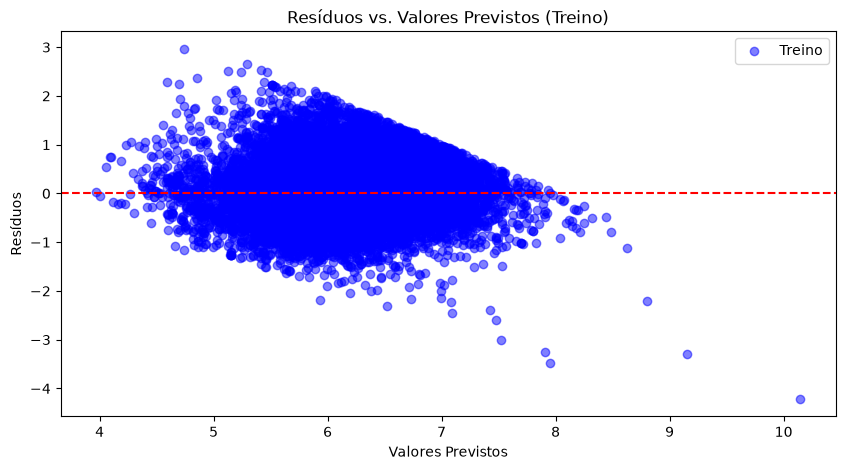

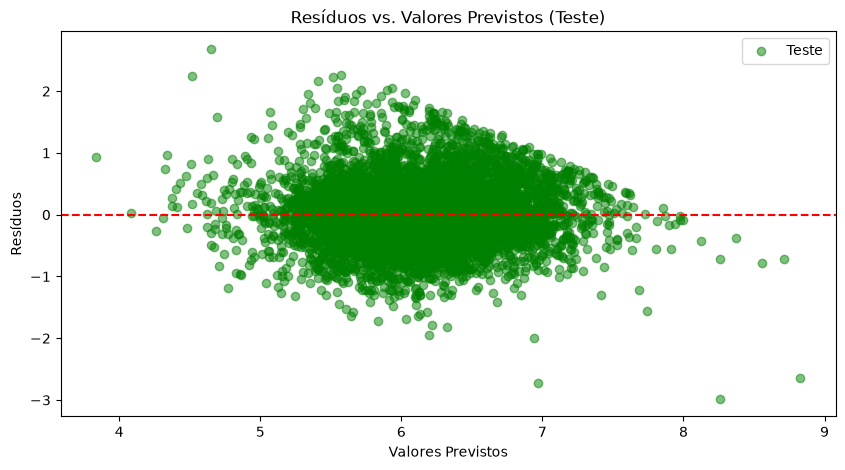

In [161]:
# Calculando os resíduos para o conjunto de treino
residuos_treino = y_treino - y_pred_treino_v1

# Calculando os resíduos para o conjunto de teste
residuos_teste = y_teste - y_pred_teste_v1

# Plotando os resíduos do conjunto de treino
plt.figure(figsize = (10, 5))
plt.scatter(y_pred_treino_v1, residuos_treino, color = 'blue', label = 'Treino', alpha = 0.5)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Previstos (Treino)')
plt.legend()
plt.show()

# Plotando os resíduos do conjunto de teste
plt.figure(figsize = (10, 5))
plt.scatter(y_pred_teste_v1, residuos_teste, color = 'green', label = 'Teste', alpha = 0.5)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Resíduos vs. Valores Previstos (Teste)')
plt.legend()
plt.show()

## 7- Deploy e Uso do Modelo Para Previsão com Novos Dados

In [174]:
# Salva o scaler
joblib.dump(scaler, 'rio_scaler.pkl')

# Salva o modelo
joblib.dump(modelo_dsa_v1, 'modelo_v1_rio.pkl')

['modelo_v1_rio.pkl']

In [175]:
# Isso deveria ter sido salvo JUNTO com o modelo, na etapa de treino:

joblib.dump(media_por_bairro, 'mapa_bairro_score.pkl')
joblib.dump(media_por_tipo, 'mapa_property_type_score.pkl')

['mapa_property_type_score.pkl']

In [176]:

# Carrega padronizador, modelo e os mapas de score
scaler_final = joblib.load('rio_scaler.pkl')
modelo_final = joblib.load('modelo_v1_rio.pkl')
mapa_bairro = joblib.load('mapa_bairro_score.pkl')
mapa_property_type = joblib.load('mapa_property_type_score.pkl')

In [177]:
# --- Entrada de um novo imóvel (exemplo) ---
entrada_bruta = {
    'hosts_time_as_host_months': 12,
    'latitude': -22.9707,
    'longitude': -43.1823,
    'accommodates': 4,
    'bathrooms': 2.0,
    'bedrooms': 2,
    'beds': 2,
    'minimum_nights': 2,
    'maximum_nights': 30,
    'availability_365': 200,
    'estimated_occupancy_l365d': 60,
    'review_scores_rating': 4.8,
    'calculated_host_listings_count': 1,
    'room_type_Private room': 0,
    'room_type_Shared room': 0,
    'neighbourhood_cleansed': 'Ipanema',
    'property_type': 'Entire rental unit'
}

# --- Validação de entrada ---
if entrada_bruta['neighbourhood_cleansed'] not in mapa_bairro:
    print(f"Aviso: bairro '{entrada_bruta['neighbourhood_cleansed']}' não encontrado no treino. Usando valor médio.")

if entrada_bruta['property_type'] not in mapa_property_type:
    print(f"Aviso: tipo de imóvel '{entrada_bruta['property_type']}' não encontrado no treino. Usando valor médio.")

# Traduzindo bairro e tipo de imóvel nos scores que o modelo espera
bairro_score = mapa_bairro.get(entrada_bruta['neighbourhood_cleansed'], mapa_bairro.mean())
property_type_score = mapa_property_type.get(entrada_bruta['property_type'], mapa_property_type.mean())

In [178]:
# Montando o dataframe na EXATA ordem de colunas usada no treino
colunas_finais = [
    'hosts_time_as_host_months', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d', 'review_scores_rating',
    'calculated_host_listings_count', 'room_type_Private room',
    'room_type_Shared room', 'bairro_score', 'property_type_score'
]

novos_dados = pd.DataFrame([{
    **{k: entrada_bruta[k] for k in colunas_finais if k in entrada_bruta},
    'bairro_score': bairro_score,
    'property_type_score': property_type_score
}])[colunas_finais]  # garante a ordem certa


In [179]:
# Padronizando com o scaler já treinado
novos_dados_scaled = scaler_final.transform(novos_dados)


In [180]:
# Previsão
previsao = modelo_final.predict(novos_dados_scaled)

In [182]:
# Previsão
preco_previsto_log = modelo_final.predict(novos_dados_scaled)
preco_previsto_real = np.expm1(preco_previsto_log)

print(f'Preço previsto para a diária: R$ {preco_previsto_real[0]:.2f}')

Preço previsto para a diária: R$ 886.17


Outra forma:

In [183]:
def prever_preco_diaria(
    hosts_time_as_host_months, latitude, longitude, accommodates,
    bathrooms, bedrooms, beds, minimum_nights, maximum_nights,
    availability_365, estimated_occupancy_l365d, review_scores_rating,
    calculated_host_listings_count, room_type, neighbourhood_cleansed, property_type,
    scaler=scaler_final, modelo=modelo_final, mapa_bairro=mapa_bairro, mapa_property_type=mapa_property_type
):
    """
    Prevê o preço da diária de um imóvel no Rio de Janeiro, com base
    nas características informadas.

    room_type deve ser: 'Entire home/apt', 'Private room' ou 'Shared room'
    """
    # Validações
    if neighbourhood_cleansed not in mapa_bairro:
        print(f"Aviso: bairro '{neighbourhood_cleansed}' não encontrado no treino. Usando valor médio.")
    if property_type not in mapa_property_type:
        print(f"Aviso: tipo de imóvel '{property_type}' não encontrado no treino. Usando valor médio.")
    if room_type not in ['Entire home/apt', 'Private room', 'Shared room']:
        raise ValueError("room_type deve ser 'Entire home/apt', 'Private room' ou 'Shared room'")

    # Traduzindo bairro e tipo de imóvel nos scores
    bairro_score = mapa_bairro.get(neighbourhood_cleansed, mapa_bairro.mean())
    property_type_score = mapa_property_type.get(property_type, mapa_property_type.mean())

    # Convertendo room_type em dummies (mesma lógica do treino, drop_first=True)
    room_type_private = 1 if room_type == 'Private room' else 0
    room_type_shared = 1 if room_type == 'Shared room' else 0

    # Montando o dataframe na ordem exata usada no treino
    colunas_finais = [
        'hosts_time_as_host_months', 'latitude', 'longitude', 'accommodates',
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
        'availability_365', 'estimated_occupancy_l365d', 'review_scores_rating',
        'calculated_host_listings_count', 'room_type_Private room',
        'room_type_Shared room', 'bairro_score', 'property_type_score'
    ]

    dados = pd.DataFrame([{
        'hosts_time_as_host_months': hosts_time_as_host_months,
        'latitude': latitude,
        'longitude': longitude,
        'accommodates': accommodates,
        'bathrooms': bathrooms,
        'bedrooms': bedrooms,
        'beds': beds,
        'minimum_nights': minimum_nights,
        'maximum_nights': maximum_nights,
        'availability_365': availability_365,
        'estimated_occupancy_l365d': estimated_occupancy_l365d,
        'review_scores_rating': review_scores_rating,
        'calculated_host_listings_count': calculated_host_listings_count,
        'room_type_Private room': room_type_private,
        'room_type_Shared room': room_type_shared,
        'bairro_score': bairro_score,
        'property_type_score': property_type_score
    }])[colunas_finais]

    # Padronizando e prevendo
    dados_scaled = scaler.transform(dados)
    preco_log = modelo.predict(dados_scaled)
    preco_real = np.expm1(preco_log)[0]

    return round(preco_real, 2)

In [184]:
preco = prever_preco_diaria(
    hosts_time_as_host_months=12,
    latitude=-22.9707,
    longitude=-43.1823,
    accommodates=4,
    bathrooms=2.0,
    bedrooms=2,
    beds=2,
    minimum_nights=2,
    maximum_nights=30,
    availability_365=200,
    estimated_occupancy_l365d=60,
    review_scores_rating=4.8,
    calculated_host_listings_count=1,
    room_type='Entire home/apt',
    neighbourhood_cleansed='Ipanema',
    property_type='Entire rental unit'
)

print(f'Preço previsto para a diária: R$ {preco:.2f}')

Preço previsto para a diária: R$ 886.17


## CONCLUSÃO DO PROJETO — Regressão Linear para Preço de Hospedagem (Rio de Janeiro)
====================================================================================

RESULTADO FINAL
- Modelo: Regressão Linear (17 variáveis, validado com VIF, OLS e regularização)
- R² (teste): ~0.486 | RMSE (teste): ~0.498 (escala log_price)
- Lasso, Ridge e Elastic Net convergiram para o mesmo resultado do modelo linear
  simples — confirma que a seleção de variáveis já estava bem otimizada,
  sem multicolinearidade ou redundância relevante a corrigir.
- Random Forest (usado só para checagem de importância) atingiu R² ~0.61 —
  a diferença indica presença de relações não-lineares que o modelo linear
  não captura.

POR QUE O R² NÃO FOI MAIS ALTO
1. Variáveis "invisíveis" ao dataset: qualidade de fotos, texto do anúncio,
   decoração e reputação da plataforma influenciam preço real, mas não
   existem como colunas estruturadas.
2. Relações não-lineares na geografia: latitude/longitude tiveram maior
   importância no Random Forest do que na correlação linear, sugerindo
   "bolsões" de valorização que uma reta não representa bem.
3. Heterocedasticidade residual: o modelo erra mais (e de forma sistemática)
   nos preços mais altos, mesmo após transformação log e remoção de outliers.
4. Causalidade ambígua: estimated_occupancy_l365d tem relação bidirecional
   com preço (efeito e causa), dificultando uma leitura puramente causal.

MELHORIAS PARA UM PRÓXIMO PROJETO SIMILAR
- Dados adicionais: NLP no texto do anúncio, amenities específicas de alto
  impacto (piscina, vista, elevador), dados de imagem, série temporal de preço.
- Modelagem: termos de interação (lat × long), distância a múltiplos pontos
  de interesse, modelos de árvore como entrega final (XGBoost/LightGBM),
  ou GAMs para equilibrar interpretabilidade e não-linearidade.
- Pipeline: segmentar o modelo por tipo de imóvel/faixa de preço; investigar
  mais a fundo casos de maior erro residual.

CONCLUSÃO
O resultado reflete o limite real da informação disponível e do modelo
linear diante de um fenômeno parcialmente não-linear — não uma falha do
processo. O valor do projeto está no rigor da metodologia: EDA completo,
tratamento justificado de outliers, engenharia de atributos testada e
validada (scores de bairro/tipo de imóvel), seleção de variáveis por
múltiplos métodos convergentes (VIF, significância estatística, Random
Forest, regularização), e diagnóstico honesto de resíduos.